# Radar Basics: step-by-step coding notebook

这个 notebook 会按小步推进的方式学习 `radar_basics` codebase。每一步我们只写少量代码，先运行、观察，再解释它在 radar simulation mental model 里代表什么。

## Step 1: YAML 是实验说明书

先不要急着进入 `RadarSystem` 或信号处理。这个项目的入口是一份 YAML config：它描述一次雷达仿真实验需要哪些东西。

这一步我们只做三件事：

1. 找到 `example_configs/architecture.yaml`。
2. 把 YAML 读成 Python dict。
3. 看清楚它有哪些 top-level sections。

Mental model: YAML 不是仿真结果，也不是雷达对象本身；它是一次 experiment 的 declarative specification。

In [17]:
from pathlib import Path
from pprint import pprint

import yaml


def find_project_root(start: Path | None = None) -> Path:
    """Find the repository root from either the repo folder or the learning folder."""
    start = start or Path.cwd()
    for candidate in (start, *start.parents):
        config_path = candidate / "example_configs" / "architecture.yaml"
        if (candidate / "pyproject.toml").exists() and config_path.exists():
            return candidate
    raise FileNotFoundError("Could not find the radar_basics project root")


PROJECT_ROOT = find_project_root()
CONFIG_PATH = PROJECT_ROOT / "example_configs" / "architecture.yaml"

with CONFIG_PATH.open("r", encoding="utf-8") as handle:
    raw_config = yaml.safe_load(handle)

print(f"Project root: {PROJECT_ROOT}")
print(f"Config path:   {CONFIG_PATH}")

print("\nTop-level sections:")
for section_name in raw_config:
    print(f"  - {section_name}")

print("\nYAML loaded as a Python dict:")
pprint(raw_config, sort_dicts=False)

Project root: c:\Users\yanzhang\Desktop\Research_Projects\radar_basics
Config path:   c:\Users\yanzhang\Desktop\Research_Projects\radar_basics\example_configs\architecture.yaml

Top-level sections:
  - radar
  - array
  - waveform
  - scan
  - scene
  - processing
  - run

YAML loaded as a Python dict:
{'radar': {'carrier_frequency_hz': 10000000000.0,
           'peak_tx_power_w': 50000.0,
           'noise_figure_db': 0.0,
           'system_loss_db': 0.0,
           'temperature_k': 0.0},
 'array': {'num_y': 4, 'num_x': 4},
 'waveform': {'bandwidth_hz': 5000000.0,
              'pulse_width_s': 2e-06,
              'prf_hz': 10000.0,
              'num_pulses': 16,
              'sample_rate_hz': 10000000.0},
 'scan': {'azimuths_deg': [-10.0, 0.0, 10.0],
          'elevations_deg': [-5.0, 0.0, 5.0],
          'mode': 'search'},
 'scene': {'targets': [{'name': 'target-a',
                        'range_m': 1500.0,
                        'az_deg': 0.0,
                        'el_deg'

### 观察这个输出

请先重点看 top-level sections，而不是陷入每个数字的细节。

- `radar`：雷达本机参数，比如 carrier frequency、peak transmit power、noise/loss。
- `array`：阵列几何，当前是二维 rectangular planar array。
- `waveform`：LFM pulse waveform 和 CPI 相关参数。
- `scan`：雷达要看哪些 azimuth/elevation 方向。
- `scene`：truth world，里面有哪些目标。
- `processing`：处理链路的角度网格、detector、tracker 配置。
- `run`：这次实验跑几轮 scan、随机种子、是否保存 raw IQ。

暂停点：运行上面的 cell 后，确认你能回答这个问题：如果我只改 YAML 里的 `scene.targets[0].range_m`，我是在改雷达硬件、改目标真值，还是改信号处理算法？

## Step 2: Config -> Python Objects

Step 1 里，`yaml.safe_load()` 得到的是普通 nested dictionary。Python 可以处理它，但这个 dict 还没有被这个 codebase 理解成一个正式的 radar experiment。

现在我们用 `load_config()` 做下一层转换：

```text
YAML file -> nested dict -> ExperimentConfig dataclass
```

`ExperimentConfig` 的价值是：它把 loose 的 dict 变成有结构、有字段名、经过基本校验的 Python object。

In [18]:
from dataclasses import fields, is_dataclass

from radar_basics import load_config


config = load_config(CONFIG_PATH)

print(f"raw_config type: {type(raw_config).__name__}")
print(f"config type:     {type(config).__name__}")
print(f"is dataclass:    {is_dataclass(config)}")

print("\nTop-level config objects:")
for field in fields(config):
    value = getattr(config, field.name)
    print(f"  {field.name:<10} -> {type(value).__name__}")

print("\nA few concrete fields:")
print(f"carrier_frequency_hz = {config.radar.carrier_frequency_hz:,.1f}")
print(f"array size           = {config.array.num_y} x {config.array.num_x}")
print(f"num_pulses           = {config.waveform.num_pulses}")
print(f"scan azimuths        = {config.scan.azimuths_deg}")
print(f"scan elevations      = {config.scan.elevations_deg}")
print(f"target count         = {len(config.scene.targets)}")
print(f"run scan cycles      = {config.run.num_scan_cycles}")

raw_config type: dict
config type:     ExperimentConfig
is dataclass:    True

Top-level config objects:
  radar      -> RadarConfig
  array      -> ArrayConfig
  waveform   -> WaveformConfig
  scan       -> ScanConfig
  scene      -> SceneConfig
  processing -> ProcessingConfig
  run        -> RunConfig

A few concrete fields:
carrier_frequency_hz = 10,000,000,000.0
array size           = 4 x 4
num_pulses           = 16
scan azimuths        = (-10.0, 0.0, 10.0)
scan elevations      = (-5.0, 0.0, 5.0)
target count         = 1
run scan cycles      = 2


### 观察这个输出

这里有一个重要分层：

- `raw_config` 是普通 `dict`，来自 YAML parser。
- `config` 是 `ExperimentConfig`，来自 `radar_basics.config.load_config()`。
- `config.radar`、`config.array`、`config.waveform` 等字段也各自是 dataclass object。

这一步还没有创建真正会参与仿真的 runtime objects。比如现在的 `config.radar` 只是雷达配置；下一步 Step 3A 里，我们会用它 build 出真正的 `RadarSystem`。

暂停点：请确认你能区分这三层：YAML text、Python dict、`ExperimentConfig` dataclass。

### My understanding after Step 2

到目前为止，可以把这三种形式理解成同一份 simulation specification 的不同表示：

```text
YAML text -> raw_config dictionary -> ExperimentConfig dataclass
```

它们表达的信息本质上是一样的：都是这次 radar simulation 需要的参数。区别主要在数据组织方式：

- YAML 方便人类阅读和编辑。
- `raw_config` 是 Python 可以直接处理的 nested `dict` / `list`。
- `ExperimentConfig` 是更结构化的 dataclass object，把 `radar`、`array`、`waveform`、`scan`、`scene`、`processing`、`run` 分别放进对应的 config dataclass。

这个 dataclass abstraction 对小项目来说看起来有点重，但它提供了字段结构、基本校验和更清楚的代码接口。

真正重要的边界是下一步：

```text
ExperimentConfig -> RadarSystem / Scene / Scheduler
```

从这里开始，就不只是同一份参数换一种组织方式了，而是会 build 出有行为的 runtime objects。比如 `RadarSystem` 可以计算 wavelength/range resolution，`Scene` 可以在某个时间产生 target snapshot，`Scheduler` 可以生成 dwell tasks。

## Step 3A: Radar Module

现在开始从 config specification 进入 runtime objects。第一站是 `radar_basics.radar`。

这一步我们只学习 radar 这一层：

- `config.radar`、`config.array`、`config.waveform` 是配置参数。
- `build_radar_system(config)` 会把这些参数 build 成一个 `RadarSystem`。
- `RadarSystem` 里面包含真正参与仿真的 `RectangularArray` 和 `LfmPulseWaveform`。

Mental model: `RadarSystem` 代表“这台雷达是什么样的”。它不包含目标，也不包含扫描任务；它只描述硬件、阵列、波形和由这些参数推导出来的雷达能力。

In [19]:
from radar_basics import build_radar_system


radar = build_radar_system(config)
array = radar.array
waveform = radar.waveform

print("Config objects -> runtime object")
print(f"config.radar type:    {type(config.radar).__name__}")
print(f"config.array type:    {type(config.array).__name__}")
print(f"config.waveform type: {type(config.waveform).__name__}")
print(f"radar type:           {type(radar).__name__}")

print("\nRadarSystem: derived quantities")
print(f"carrier_frequency_hz       = {radar.carrier_frequency_hz:,.1f} Hz")
print(f"wavelength_m               = {radar.wavelength_m:.6f} m")
print(f"max_unambiguous_range_m    = {radar.max_unambiguous_range_m:,.2f} m")
print(f"range_resolution_m         = {radar.range_resolution_m:.2f} m")
print(f"velocity_resolution_mps    = {radar.velocity_resolution_mps:.2f} m/s")
print(f"max_unambiguous_velocity_mps = {radar.max_unambiguous_velocity_mps:.2f} m/s")
print(f"noise_power_w              = {radar.noise_power_w:.3e} W")

print("\nRectangularArray: element geometry")
print(f"array type        = {type(array).__name__}")
print(f"num_y x num_x     = {array.num_y} x {array.num_x}")
print(f"num_elements      = {array.num_elements}")
print(f"spacing_y_m       = {array.spacing_y_m:.6f} m")
print(f"spacing_x_m       = {array.spacing_x_m:.6f} m")
print(f"positions_m shape = {array.positions_m.shape}")
print(f"corner element 0  = {array.positions_m[0, 0]}")
print(f"corner element -1 = {array.positions_m[-1, -1]}")

print("\nLfmPulseWaveform: pulse and CPI settings")
print(f"waveform type          = {type(waveform).__name__}")
print(f"bandwidth_hz           = {waveform.bandwidth_hz:,.1f} Hz")
print(f"pulse_width_s          = {waveform.pulse_width_s:.3e} s")
print(f"prf_hz                 = {waveform.prf_hz:,.1f} Hz")
print(f"pri_s                  = {waveform.pri_s:.3e} s")
print(f"num_pulses             = {waveform.num_pulses}")
print(f"sample_rate_hz         = {waveform.sample_rate_hz:,.1f} Hz")
print(f"num_fast_time_samples  = {waveform.num_fast_time_samples}")
print(f"num_pulse_samples      = {waveform.num_pulse_samples}")

Config objects -> runtime object
config.radar type:    RadarConfig
config.array type:    ArrayConfig
config.waveform type: WaveformConfig
radar type:           RadarSystem

RadarSystem: derived quantities
carrier_frequency_hz       = 10,000,000,000.0 Hz
wavelength_m               = 0.029979 m
max_unambiguous_range_m    = 14,989.62 m
range_resolution_m         = 29.98 m
velocity_resolution_mps    = 9.37 m/s
max_unambiguous_velocity_mps = 74.95 m/s
noise_power_w              = 0.000e+00 W

RectangularArray: element geometry
array type        = RectangularArray
num_y x num_x     = 4 x 4
num_elements      = 16
spacing_y_m       = 0.014990 m
spacing_x_m       = 0.014990 m
positions_m shape = (4, 4, 3)
corner element 0  = [ 0.         -0.02248443 -0.02248443]
corner element -1 = [0.         0.02248443 0.02248443]

LfmPulseWaveform: pulse and CPI settings
waveform type          = LfmPulseWaveform
bandwidth_hz           = 5,000,000.0 Hz
pulse_width_s          = 2.000e-06 s
prf_hz              

### 观察这个输出

这里开始出现真正的 runtime behavior：

- `config.radar` 是 `RadarConfig`，只是参数容器。
- `radar` 是 `RadarSystem`，它可以根据参数计算 `wavelength_m`、`range_resolution_m`、`velocity_resolution_mps` 等派生量。
- `radar.array` 是 `RectangularArray`，它知道阵元数量、间距和每个阵元的三维坐标。
- `radar.waveform` 是 `LfmPulseWaveform`，它知道 PRI、fast-time samples、pulse samples 等波形行为。

请先不要背公式，先抓住这个边界：YAML/config 只保存参数；`RadarSystem` 开始把参数变成可以计算、可以参与仿真的对象。

暂停点：请确认你能解释 `config.waveform.num_pulses` 和 `radar.waveform.num_pulses` 的关系，以及为什么 `radar.wavelength_m` 不需要直接写在 YAML 里。

### My understanding after Step 3A

就是说 step 3A 这个 radar object 表示的就是硬件上的雷达系统：包括 antenna array (存储的信息有： 每一个 element 的位置， 每一个 element 的 steering vector), transmit gain 的信息；包括 waveform （存储的信息有：lfm 的参数， pri, fast-time, slow-time 这些信息， 还有就是一个 chirp 的 sample values 这些。；包括其他一些 radar performance specs 的参数（carrier freq, unambiguous range, ... 这些）。

## Step 3B: Scene Module

现在学习 `radar_basics.scenario`。如果 Step 3A 的 `radar` 描述“这台雷达是什么样的”，那么 Step 3B 的 `scene` 描述“外部世界里有什么目标”。

这一步我们只学习 truth world：

- `config.scene` 是场景配置。
- `build_scene(config)` 会创建 runtime `Scene`。
- `Scene` 里面包含一个或多个 `PointTarget`。
- `Scene.snapshots_at(time_s)` 会在指定时间生成 `TargetSnapshot`。

Mental model: `Scene` 不是 measurement，也不是 detection。它是真值层，告诉仿真器目标真实在哪里、怎么运动、RCS 是多少。

In [20]:
from radar_basics import build_scene


scene = build_scene(config)

print("Config object -> runtime object")
print(f"config.scene type: {type(config.scene).__name__}")
print(f"scene type:        {type(scene).__name__}")
print(f"target count:      {len(scene.targets)}")

print("\nPointTarget objects stored inside Scene:")
for target in scene.targets:
    print(f"target type:   {type(target).__name__}")
    print(f"name:          {target.name}")
    print(f"position_m:    {target.position_m}")
    print(f"velocity_mps:  {target.velocity_mps}")
    print(f"rcs_m2:        {target.rcs_m2}")

snapshot_t0 = scene.snapshots_at(0.0)[0]
snapshot_t1 = scene.snapshots_at(1.0)[0]

print("\nTargetSnapshot at t = 0.0 s:")
print(f"snapshot type:        {type(snapshot_t0).__name__}")
print(f"name:                 {snapshot_t0.name}")
print(f"position_m:           {snapshot_t0.position_m}")
print(f"velocity_mps:         {snapshot_t0.velocity_mps}")
print(f"range_m:              {snapshot_t0.range_m:.2f}")
print(f"az_deg:               {snapshot_t0.az_deg:.2f}")
print(f"el_deg:               {snapshot_t0.el_deg:.2f}")
print(f"radial_velocity_mps:  {snapshot_t0.radial_velocity_mps:.2f}")
print(f"rcs_m2:               {snapshot_t0.rcs_m2}")

print("\nCompare t = 0.0 s and t = 1.0 s:")
print(f"position at t0: {snapshot_t0.position_m}")
print(f"position at t1: {snapshot_t1.position_m}")
print(f"range at t0:    {snapshot_t0.range_m:.2f} m")
print(f"range at t1:    {snapshot_t1.range_m:.2f} m")

Config object -> runtime object
config.scene type: SceneConfig
scene type:        Scene
target count:      1

PointTarget objects stored inside Scene:
target type:   PointTarget
name:          target-a
position_m:    (1500.0, 0.0, 0.0)
velocity_mps:  (0.0, 0.0, 0.0)
rcs_m2:        10.0

TargetSnapshot at t = 0.0 s:
snapshot type:        TargetSnapshot
name:                 target-a
position_m:           [1500.    0.    0.]
velocity_mps:         [0. 0. 0.]
range_m:              1500.00
az_deg:               0.00
el_deg:               0.00
radial_velocity_mps:  0.00
rcs_m2:               10.0

Compare t = 0.0 s and t = 1.0 s:
position at t0: [1500.    0.    0.]
position at t1: [1500.    0.    0.]
range at t0:    1500.00 m
range at t1:    1500.00 m


### 观察这个输出

这里的关键边界是：

- `PointTarget` 保存目标的基础真值：名字、三维位置、三维速度、RCS。
- `TargetSnapshot` 是某个具体时间点的目标状态，会额外计算出 `range_m`、`az_deg`、`el_deg`、`radial_velocity_mps`。
- `radial_velocity_mps` 是速度在 radar line-of-sight 方向上的分量，不一定等于完整三维速度的大小。

当前 example config 里的目标径向速度是 `10.0 m/s`。因为这个 config 用的是 `range_m` / `az_deg` / `el_deg` / `radial_velocity_mps` 写法，parser 会把径向速度转换成沿 line-of-sight 方向的三维速度。

所以 `t = 0.0 s` 和 `t = 1.0 s` 的 position/range 不再相同：目标会沿当前视线方向移动约 `10 m`，range 也会增加约 `10 m`。

暂停点：请确认你能解释 `PointTarget` 和 `TargetSnapshot` 的区别，以及为什么 `Scene` 是 truth world 而不是 radar measurement。

## Step 3C: Scheduler Module

现在学习 `radar_basics.scheduler`。如果 `radar` 是硬件和波形，`scene` 是真实世界目标，那么 `scheduler` 描述雷达的操作计划：什么时候看哪个方向。

这一步我们只学习 scan schedule：

- `config.scan` 保存 scan grid，比如 azimuths 和 elevations。
- `ScriptedScanScheduler` 把 scan grid 展开成一串 `DwellTask`。
- 每个 `DwellTask` 表示一次 dwell / CPI：雷达在一个时间段内看一个 look direction。

Mental model: 雷达不是一次看完整空间，而是按 dwell 一个方向一个方向地看。scheduler 负责把“我要扫这些方向”变成具体执行顺序。

In [21]:
from radar_basics.scheduler import ScriptedScanScheduler


scheduler = ScriptedScanScheduler(
    azimuths_deg=config.scan.azimuths_deg,
    elevations_deg=config.scan.elevations_deg,
    prf_hz=radar.waveform.prf_hz,
    num_pulses=radar.waveform.num_pulses,
    mode=config.scan.mode,
)

tasks = scheduler.tasks(num_scan_cycles=config.run.num_scan_cycles)

print("Config scan -> scheduler -> dwell tasks")
print(f"config.scan type:     {type(config.scan).__name__}")
print(f"scheduler type:       {type(scheduler).__name__}")
print(f"azimuths_deg:         {scheduler.azimuths_deg}")
print(f"elevations_deg:       {scheduler.elevations_deg}")
print(f"num_scan_cycles:      {config.run.num_scan_cycles}")
print(f"tasks count:          {len(tasks)}")

expected_tasks = (
    len(config.scan.azimuths_deg)
    * len(config.scan.elevations_deg)
    * config.run.num_scan_cycles
)
print(f"expected tasks count: {expected_tasks}")

print("\nFirst few DwellTask objects:")
for task in tasks[:6]:
    print(
        f"id={task.id:2d} "
        f"look=({task.look_az_deg:5.1f} deg az, {task.look_el_deg:5.1f} deg el) "
        f"start={task.start_time_s:.6f} s "
        f"duration={task.duration_s:.6f} s "
        f"center={task.center_time_s:.6f} s "
        f"pulses={task.num_pulses}"
    )

print("\nLast DwellTask:")
last_task = tasks[-1]
print(last_task)

print("\nScan order as (azimuth, elevation):")
print([(task.look_az_deg, task.look_el_deg) for task in tasks])

Config scan -> scheduler -> dwell tasks
config.scan type:     ScanConfig
scheduler type:       ScriptedScanScheduler
azimuths_deg:         (-10.0, 0.0, 10.0)
elevations_deg:       (-5.0, 0.0, 5.0)
num_scan_cycles:      2
tasks count:          18
expected tasks count: 18

First few DwellTask objects:
id= 0 look=(-10.0 deg az,  -5.0 deg el) start=0.000000 s duration=0.001600 s center=0.000800 s pulses=16
id= 1 look=(  0.0 deg az,  -5.0 deg el) start=0.001600 s duration=0.001600 s center=0.002400 s pulses=16
id= 2 look=( 10.0 deg az,  -5.0 deg el) start=0.003200 s duration=0.001600 s center=0.004000 s pulses=16
id= 3 look=(-10.0 deg az,   0.0 deg el) start=0.004800 s duration=0.001600 s center=0.005600 s pulses=16
id= 4 look=(  0.0 deg az,   0.0 deg el) start=0.006400 s duration=0.001600 s center=0.007200 s pulses=16
id= 5 look=( 10.0 deg az,   0.0 deg el) start=0.008000 s duration=0.001600 s center=0.008800 s pulses=16

Last DwellTask:
DwellTask(id=17, mode='search', look_az_deg=10.0, lo

### 观察这个输出

这里的关键对象是 `DwellTask`。它不是目标，也不是数据；它是一条执行指令：

```text
at this time, use this PRF and this many pulses, look at this az/el direction
```

几个重要字段：

- `look_az_deg` / `look_el_deg`：这次 dwell 的波束指向。
- `start_time_s`：这次 dwell 开始时间。
- `num_pulses` 和 `prf_hz`：这次 dwell 的 CPI 设置。
- `duration_s`：由 `num_pulses / prf_hz` 推导出来。
- `center_time_s`：这次 dwell 的中心时间，后面常用于 target truth snapshot 和 detection timestamp。

暂停点：请确认你能解释为什么 3 个 azimuth、3 个 elevation、2 个 scan cycles 会产生 18 个 `DwellTask`。

### My understanding after Step 3C

Scheduler 的作用是把 scan grid 展开成时间轴上的一串 `DwellTask`。

这里的 scan grid 可以理解为：按照离散的 azimuth/elevation 角度，把雷达要观察的空域划分成一组 look directions。

每个 `DwellTask` 表示一个 dwell / CPI 的执行指令：

```text
在某个时间段内，
雷达看向某个 az/el 方向，
用指定 PRF 发射指定数量的 pulses，
并收集这一段 CPI 的回波数据。
```

所以 scheduler 本身不关心目标在哪里，也不生成 IQ 数据。它只负责回答：

```text
雷达在什么时间，看哪个方向，看多久？
```

## Step 4: One Dwell Raw IQ

现在把前面三个 runtime objects 合在一起：

```text
radar + scene + one DwellTask -> RawDwellData
```

这一步调用 `synthesize_dwell()`，生成一个 dwell / CPI 的 raw complex IQ 数据。

Mental model: 一个目标在 raw IQ 里表现为三件事：

- fast-time delay：目标距离决定回波延迟。
- slow-time phase progression：径向速度决定 pulse-to-pulse phase rotation。
- array-space phase slope：目标角度决定阵元之间的 phase pattern。

这一步先只看数据结构和 shape，不急着做 signal processing。

In [22]:
import numpy as np

from radar_basics import synthesize_dwell


task = tasks[0]
raw = synthesize_dwell(
    radar=radar,
    scene=scene,
    task=task,
    rng=np.random.default_rng(config.run.seed),
)

print("Inputs to synthesize_dwell")
print(f"radar type: {type(radar).__name__}")
print(f"scene type: {type(scene).__name__}")
print(f"task:       {task}")

print("\nRawDwellData")
print(f"raw type:      {type(raw).__name__}")
print(f"raw.iq dtype:  {raw.iq.dtype}")
print(f"raw.iq shape:  {raw.iq.shape}")
print(
    "expected:      "
    f"({radar.array.num_y}, {radar.array.num_x}, "
    f"{task.num_pulses}, {radar.waveform.num_fast_time_samples})"
)

print("\nRaw axes")
print(f"fast_time_s shape:        {raw.axes.fast_time_s.shape}")
print(f"pulse_times_s shape:      {raw.axes.pulse_times_s.shape}")
print(f"array_positions_m shape:  {raw.axes.array_positions_m.shape}")
print(f"first 5 fast-time samples: {raw.axes.fast_time_s[:5]}")
print(f"pulse times:               {raw.axes.pulse_times_s}")

print("\nTruth snapshot attached to this dwell")
truth = raw.truth[0]
print(f"truth type:           {type(truth).__name__}")
print(f"truth time approx:    task.center_time_s = {task.center_time_s:.6f} s")
print(f"range_m:              {truth.range_m:.2f}")
print(f"az_deg / el_deg:      {truth.az_deg:.2f} / {truth.el_deg:.2f}")
print(f"radial_velocity_mps:  {truth.radial_velocity_mps:.2f}")

magnitude = np.abs(raw.iq)
max_index = np.unravel_index(np.argmax(magnitude), magnitude.shape)
print("\nWhere is the largest IQ magnitude?")
print("index order: (array_y, array_x, pulse, fast_time)")
print(f"max index:     {max_index}")
print(f"max magnitude: {magnitude[max_index]:.3e}")

power_by_fast_time = np.max(magnitude, axis=(0, 1, 2))
active_fast_time_indices = np.flatnonzero(power_by_fast_time > 0.0)
print("\nFast-time samples containing nonzero echo energy")
print(f"first active index: {active_fast_time_indices[0]}")
print(f"last active index:  {active_fast_time_indices[-1]}")
print(f"active sample count: {len(active_fast_time_indices)}")

Inputs to synthesize_dwell
radar type: RadarSystem
scene type: Scene
task:       DwellTask(id=0, mode='search', look_az_deg=-10.0, look_el_deg=-5.0, start_time_s=0.0, prf_hz=10000.0, num_pulses=16)

RawDwellData
raw type:      RawDwellData
raw.iq dtype:  complex128
raw.iq shape:  (4, 4, 16, 1000)
expected:      (4, 4, 16, 1000)

Raw axes
fast_time_s shape:        (1000,)
pulse_times_s shape:      (16,)
array_positions_m shape:  (4, 4, 3)
first 5 fast-time samples: [0.e+00 1.e-07 2.e-07 3.e-07 4.e-07]
pulse times:               [0.     0.0001 0.0002 0.0003 0.0004 0.0005 0.0006 0.0007 0.0008 0.0009
 0.001  0.0011 0.0012 0.0013 0.0014 0.0015]

Truth snapshot attached to this dwell
truth type:           TargetSnapshot
truth time approx:    task.center_time_s = 0.000800 s
range_m:              1500.00
az_deg / el_deg:      0.00 / 0.00
radial_velocity_mps:  0.00

Where is the largest IQ magnitude?
index order: (array_y, array_x, pulse, fast_time)
max index:     (np.int64(0), np.int64(0), np.

### 观察这个输出

`raw.iq` 是这个 codebase 里第一个真正的 waveform-level 数据张量：

```text
raw.iq shape = (num_y, num_x, num_pulses, num_fast_time)
```

四个维度分别表示：

- `num_y`：阵列第一个空间维度。
- `num_x`：阵列第二个空间维度。
- `num_pulses`：slow time / pulse index。
- `num_fast_time`：fast time / ADC sample index。

这一步的核心是：`synthesize_dwell()` 把三类 runtime object 合并了起来。

```text
RadarSystem: 这台雷达怎么发、怎么收
Scene:       目标真实在哪里、怎么运动
DwellTask:   这一段时间雷达看哪个方向
```

暂停点：请确认你能解释为什么 raw IQ 需要同时有 array、pulse、fast-time 三类维度。

### Reference: `synthesize_dwell()` implements this signal model

对一个 target，`synthesize_dwell()` 实现的核心 raw IQ 公式可以写成：

$$
x_{e,p,n}
=
A_p
\cdot
e^{-j\frac{4\pi R_p}{\lambda}}
\cdot
e^{j\frac{2\pi}{\lambda}\mathbf{r}_e \cdot \mathbf{u}_p}
\cdot
s(t_n - \tau_p)
$$

这里 $e$ 是 array element index，$p$ 是 pulse index，$n$ 是 fast-time sample index。因此 $x_{e,p,n}$ 就是某个阵元、某个 pulse、某个 fast-time sample 上的 complex IQ value。

各项含义：

1. 双程延迟

   $$
   \tau_p = \frac{2R_p}{c}
   $$

   $R_p$ 是目标在第 $p$ 个 pulse 时刻的 range。这个 delay 决定目标回波落在 fast-time 轴上的哪个位置。

2. Delayed LFM chirp

   $$
   s(t) = e^{j\pi Kt^2}, \quad 0 \le t < T_p, \quad K = \frac{B}{T_p}
   $$

   $s(t_n - \tau_p)$ 表示目标回波是一个被 delay 之后的 LFM chirp。

3. 双程传播相位

   $$
   e^{-j\frac{4\pi R_p}{\lambda}}
   $$

   如果目标在运动，$R_p$ 会随着 pulse index $p$ 改变，于是这个相位会在 slow time 上旋转，形成 Doppler 信息。

4. 阵列空间相位

   $$
   e^{j\frac{2\pi}{\lambda}\mathbf{r}_e \cdot \mathbf{u}_p}
   $$

   $\mathbf{r}_e$ 是第 $e$ 个阵元的位置，$\mathbf{u}_p$ 是雷达到目标方向的 unit direction vector。不同阵元位置不同，所以相位不同；这个 spatial phase pattern 后面用于 angle beamforming。

5. 幅度项

   $$
   A_p
   =
   \sqrt{\frac{P_t N \lambda^2 \sigma}{(4\pi)^3 R_p^4 L}}
   \cdot
   G_{tx}(\mathbf{u}_{look}, \mathbf{u}_p)
   $$

   这里 $P_t$ 是 transmit peak power，$N$ 是阵元数量，$\lambda$ 是 wavelength，$\sigma$ 是 target RCS，$L$ 是 system loss。$G_{tx}$ 表示这次 dwell 的 beam look direction 和目标真实方向的匹配程度。

多个 target 的情况，就是把“一个 target 的公式”线性叠加：

$$
x_{e,p,n} = \sum_{q \in targets} x^{(q)}_{e,p,n} + w_{e,p,n}
$$

$w_{e,p,n}$ 是 complex Gaussian noise。

一句话总结：`synthesize_dwell()` implement 的就是这个公式。它对每个 target、每个 pulse、每个阵元，把 delayed LFM chirp、传播相位、阵列相位、transmit gain 和 radar-equation amplitude 写进 raw IQ tensor；多个 target 线性叠加，最后加噪声。

### 我的理解

到目前为止，这个 codebase 的主线是：

```text
YAML spec
-> Python dict
-> dataclass config
-> runtime objects: radar / scene / tasks
-> synthesize_dwell()
-> one CPI raw IQ data
```

YAML 文件可以理解为一次 radar simulation 的 specification。它用人类容易阅读和修改的方式，描述雷达系统、目标场景、扫描方式、处理参数和运行参数。

`load_config()` 做的事情，是把这份 YAML 先读成 Python dictionary，再转换成结构化的 dataclass config。这个阶段本质上还是同一份参数，只是组织方式变得更适合 Python 程序使用。

然后 codebase 会根据 config 构建几个重要的 runtime objects：

- `radar`：描述这台 2D phased-array radar 的硬件和 waveform model，比如阵列、LFM pulse、carrier frequency、PRF、range/velocity resolution 等。
- `scene`：描述真实世界里的目标状态和运动模型，比如目标位置、速度、RCS，以及某个时间点的 range/az/el/radial velocity。
- `tasks`：由 scheduler 生成，描述雷达在时间轴上的操作计划。每个 `DwellTask` 表示某个时间段内，雷达看向某个 az/el 方向，并收集一个 CPI 的数据。

所以可以把 `radar`、`scene`、`tasks` 理解成把仿真的“舞台”和“参与者”搭建好了：

```text
radar: 雷达怎么发、怎么收
scene: 真实世界里有什么目标
task:  这一段时间雷达看哪个方向
```

接下来，`synthesize_dwell(radar, scene, task)` 就让这三者发生 interaction。它根据雷达参数、目标真值和当前 dwell 的 look direction，生成这一段 CPI 内接收机看到的 waveform-level raw complex IQ data。

也就是说：

```text
synthesize_dwell()
= 把目标的 range / velocity / angle / RCS
  通过雷达信号模型
  写进 raw IQ tensor
```

输出的 `raw.iq` 就是一个 dwell 的接收数据：

```text
raw.iq shape = (array_y, array_x, pulse, fast_time)
```

- array 维度承载 angle / spatial phase 信息。
- pulse 维度承载 Doppler / velocity 信息。
- fast-time 维度承载 range / delay 信息。

一个重要补充是：`radar`、`scene` 不只是“存参数”。它们也有 runtime behavior，比如 `radar` 可以计算 wavelength、steering vector、noise power；`scene` 可以在任意时间生成 target snapshot。

## Step 5A: Range Compression

现在进入 processing chain 的第一步：range compression。

Step 4 里，目标回波在 raw IQ 的 fast-time 维度上还是一个 delayed LFM chirp。Range compression 的作用是用 matched filter 把这个 chirp 压成一个 sharp peak。

Mental model:

```text
raw delayed chirp along fast time
-> matched filtering with transmitted chirp
-> range peak
```

这一步只处理 fast-time 维度。array 维度和 pulse 维度还保留着，后面会继续用于 angle 和 Doppler processing。

In [23]:
from radar_basics import SPEED_OF_LIGHT, range_compress


range_data = range_compress(raw, radar)

range_axis_m = (
    np.arange(range_data.shape[-1], dtype=float)
    * SPEED_OF_LIGHT
    / (2.0 * radar.waveform.sample_rate_hz)
)

print("Range compression")
print(f"raw.iq shape:      {raw.iq.shape}")
print(f"range_data shape:  {range_data.shape}")
print("shape order:       (array_y, array_x, pulse, range_bin)")

raw_mag = np.abs(raw.iq)
range_mag = np.abs(range_data)

raw_peak_index = np.unravel_index(np.argmax(raw_mag), raw_mag.shape)
range_peak_index = np.unravel_index(np.argmax(range_mag), range_mag.shape)

print("\nPeak before and after range compression")
print("index order: (array_y, array_x, pulse, fast_time/range_bin)")
print(f"raw peak index:        {raw_peak_index}")
print(f"compressed peak index: {range_peak_index}")

peak_range_bin = range_peak_index[-1]
print(f"compressed peak range bin: {peak_range_bin}")
print(f"compressed peak range:     {range_axis_m[peak_range_bin]:.2f} m")
print(f"truth range:               {raw.truth[0].range_m:.2f} m")
print(f"range bin spacing:         {range_axis_m[1] - range_axis_m[0]:.2f} m")

single_channel_raw = raw_mag[0, 0, 0]
single_channel_compressed = range_mag[0, 0, 0]

print("\nSingle channel width intuition")
print(f"raw active sample count:        {np.count_nonzero(single_channel_raw > 0.0)}")
print(f"compressed samples above 50% peak: {np.count_nonzero(single_channel_compressed > 0.5 * single_channel_compressed.max())}")

Range compression
raw.iq shape:      (4, 4, 16, 1000)
range_data shape:  (4, 4, 16, 1000)
shape order:       (array_y, array_x, pulse, range_bin)

Peak before and after range compression
index order: (array_y, array_x, pulse, fast_time/range_bin)
raw peak index:        (np.int64(0), np.int64(0), np.int64(0), np.int64(104))
compressed peak index: (np.int64(0), np.int64(0), np.int64(0), np.int64(100))
compressed peak range bin: 100
compressed peak range:     1498.96 m
truth range:               1500.00 m
range bin spacing:         14.99 m

Single channel width intuition
raw active sample count:        20
compressed samples above 50% peak: 3


### 观察这个输出

`range_compress(raw, radar)` 的输入是 `RawDwellData`，输出还是一个 complex ndarray：

```text
range_data shape = (array_y, array_x, pulse, range_bin)
```

shape 看起来和 `raw.iq` 一样，但最后一个维度的含义变了：

- range compression 之前：最后一维是 raw fast-time samples，里面是一段 delayed chirp。
- range compression 之后：最后一维可以理解成 range bins，目标会变成比较尖的 peak。

这一步只回答一个问题：目标在哪个 range bin？

暂停点：请确认你能解释为什么 range compression 只改变 fast-time 维度的含义，而没有消除 array 维度和 pulse 维度。

### Step 5A.1: Dissect `range_compress()`

现在把 `range_compress()` 拆开看。它本质上是在 raw IQ 的最后一维，也就是 fast-time 维度上做 matched filtering。

`src/radar_basics/processing.py` 里的实现逻辑是：

```text
waveform_samples
-> matched_filter = conjugate(reverse(waveform_samples))
-> FFT(raw IQ along fast time)
-> FFT(matched filter)
-> multiply spectra
-> IFFT back to time/range bins
-> crop to original fast-time length
```

数学上，它就是把接收信号和发射 chirp 的 matched filter 做卷积。代码用 FFT 来实现这个卷积，是为了效率。

In [24]:
# Manually reproduce radar_basics.processing.range_compress(raw, radar)
waveform_samples = radar.waveform.samples()
matched_filter = np.conj(waveform_samples[::-1])

num_fast_time = raw.iq.shape[-1]
full_length = num_fast_time + waveform_samples.size - 1

spectrum = np.fft.fft(raw.iq, n=full_length, axis=-1)
filter_spectrum = np.fft.fft(matched_filter, n=full_length)
compressed_full = np.fft.ifft(spectrum * filter_spectrum, axis=-1)

start = waveform_samples.size - 1
compressed_manual = compressed_full[..., start : start + num_fast_time]

print("Manual range_compress reproduction")
print(f"waveform_samples shape: {waveform_samples.shape}")
print(f"matched_filter shape:   {matched_filter.shape}")
print(f"num_fast_time:          {num_fast_time}")
print(f"full_length:            {full_length}")
print(f"spectrum shape:         {spectrum.shape}")
print(f"filter_spectrum shape:  {filter_spectrum.shape}")
print(f"compressed_full shape:  {compressed_full.shape}")
print(f"crop start:             {start}")
print(f"compressed_manual shape:{compressed_manual.shape}")
print(f"matches range_data:     {np.allclose(compressed_manual, range_data)}")

Manual range_compress reproduction
waveform_samples shape: (20,)
matched_filter shape:   (20,)
num_fast_time:          1000
full_length:            1019
spectrum shape:         (4, 4, 16, 1019)
filter_spectrum shape:  (1019,)
compressed_full shape:  (4, 4, 16, 1019)
crop start:             19
compressed_manual shape:(4, 4, 16, 1000)
matches range_data:     True


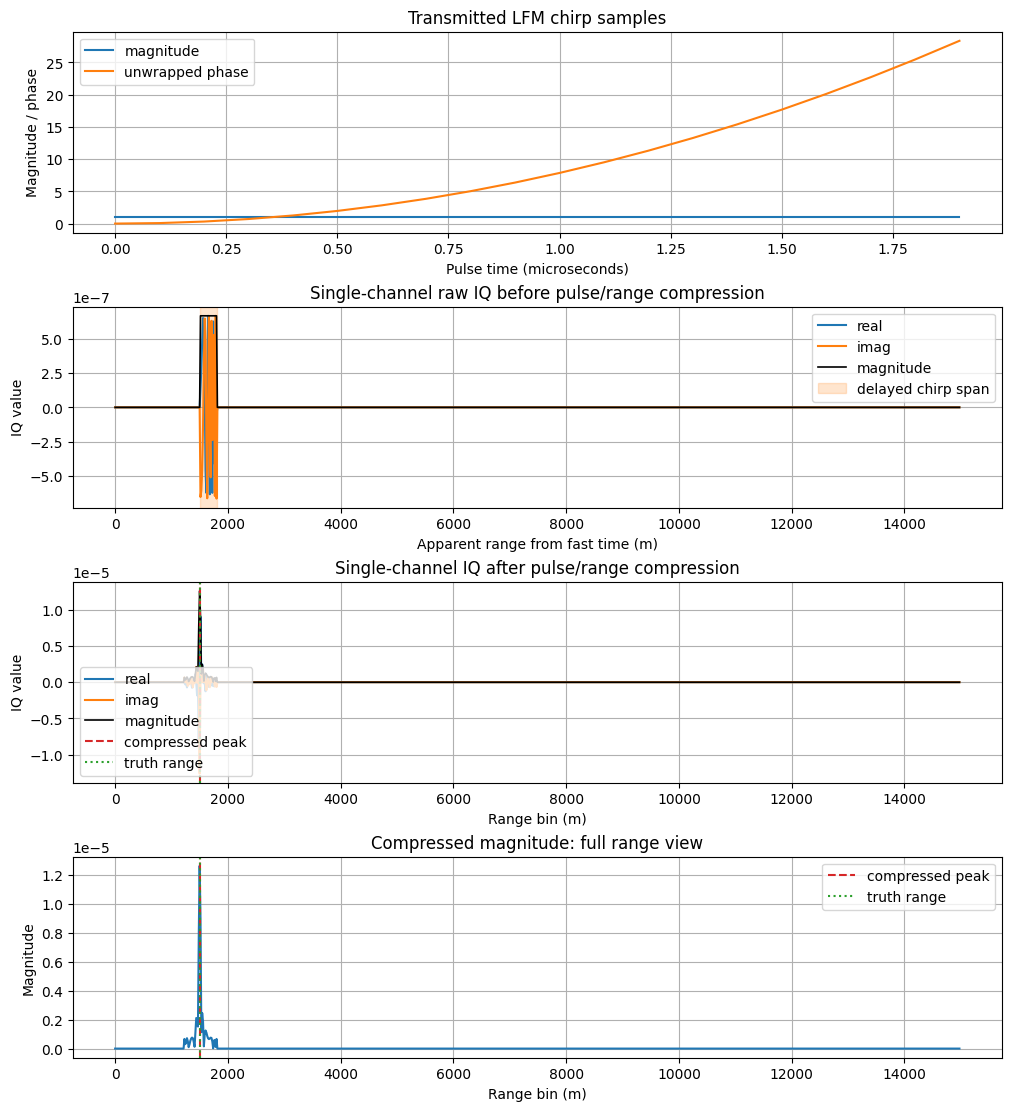

In [25]:
import matplotlib.pyplot as plt


pulse_sample_axis_us = np.arange(waveform_samples.size) / radar.waveform.sample_rate_hz * 1e6
fast_time_range_axis_m = raw.axes.fast_time_s * SPEED_OF_LIGHT / 2.0

single_raw_complex = raw.iq[0, 0, 0]
single_compressed_complex = range_data[0, 0, 0]
single_raw_mag = np.abs(single_raw_complex)
single_compressed_mag = np.abs(single_compressed_complex)

active_indices = np.flatnonzero(single_raw_mag > 0.0)
active_start = int(active_indices[0])
active_stop = int(active_indices[-1])
peak_bin = int(np.argmax(single_compressed_mag))

fig, axes = plt.subplots(4, 1, figsize=(10, 11), constrained_layout=True)

axes[0].plot(pulse_sample_axis_us, np.abs(waveform_samples), label="magnitude")
axes[0].plot(pulse_sample_axis_us, np.unwrap(np.angle(waveform_samples)), label="unwrapped phase")
axes[0].set_title("Transmitted LFM chirp samples")
axes[0].set_xlabel("Pulse time (microseconds)")
axes[0].set_ylabel("Magnitude / phase")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(fast_time_range_axis_m, np.real(single_raw_complex), label="real")
axes[1].plot(fast_time_range_axis_m, np.imag(single_raw_complex), label="imag")
axes[1].plot(fast_time_range_axis_m, single_raw_mag, color="black", linewidth=1.2, label="magnitude")
axes[1].axvspan(
    fast_time_range_axis_m[active_start],
    fast_time_range_axis_m[active_stop],
    alpha=0.2,
    color="tab:orange",
    label="delayed chirp span",
)
axes[1].set_title("Single-channel raw IQ before pulse/range compression")
axes[1].set_xlabel("Apparent range from fast time (m)")
axes[1].set_ylabel("IQ value")
axes[1].grid(True)
axes[1].legend()

axes[2].plot(range_axis_m, np.real(single_compressed_complex), label="real")
axes[2].plot(range_axis_m, np.imag(single_compressed_complex), label="imag")
axes[2].plot(range_axis_m, single_compressed_mag, color="black", linewidth=1.2, label="magnitude")
axes[2].axvline(range_axis_m[peak_bin], color="tab:red", linestyle="--", label="compressed peak")
axes[2].axvline(raw.truth[0].range_m, color="tab:green", linestyle=":", label="truth range")
axes[2].set_title("Single-channel IQ after pulse/range compression")
axes[2].set_xlabel("Range bin (m)")
axes[2].set_ylabel("IQ value")
axes[2].grid(True)
axes[2].legend()

axes[3].plot(range_axis_m, single_compressed_mag)
axes[3].axvline(range_axis_m[peak_bin], color="tab:red", linestyle="--", label="compressed peak")
axes[3].axvline(raw.truth[0].range_m, color="tab:green", linestyle=":", label="truth range")
axes[3].set_title("Compressed magnitude: full range view")
axes[3].set_xlabel("Range bin (m)")
axes[3].set_ylabel("Magnitude")
axes[3].grid(True)
axes[3].legend()

display(fig)
plt.close(fig)

### How to read these plots

第一张图显示发射的 LFM chirp。它的 magnitude 基本恒定，但 phase 是二次变化的；这就是 chirp 的频率随时间扫动。

第二张图显示单个阵元、单个 pulse 的 raw complex IQ signal。蓝色和橙色分别是 real / imaginary part，黑线是 magnitude。目标在 raw IQ 里不是一个点，而是一段 delayed complex chirp。浅橙色区域标出这段回波在 fast-time/range 轴上的跨度。

第三张图显示 pulse/range compression 之后的 complex IQ signal。这里的 “pulse compression” 和代码中的 “range compression” 指同一件事：对 fast-time LFM chirp 做 matched filtering。压缩之后，复数 IQ 的能量集中到目标 range bin 附近。

第四张图只画 compressed magnitude 的 full-range view。Matched filter 会把“像发射 chirp 的那段信号”相关出来，形成一个 sharp peak。这个 peak 的 range bin 对应目标距离。

注意：range compression 只沿最后一维 fast-time 做 matched filtering。array 维度和 pulse 维度仍然保留，后面分别用于 angle processing 和 Doppler processing。

### 我的理解

这里的 pulse compression 就是对 raw_iq with shape (element_idx_x, element_idx_y, slow_time, fast_time)，对这个 fast_time  axis 用 transmit signal 做 matched filtering, 用人话讲，就是，每一个 antenna 都能接收到 M 个 pulse, 然后对每一个 pulse 做 matched filtering。

## Step 5B: Doppler Processing

Range compression 之后，我们已经把目标定位到某个 range bin 附近。下一步是 Doppler processing。

Doppler processing 的核心是：对同一个 range bin，在 pulse / slow-time 维度上做 FFT。

Mental model:

```text
pulse-to-pulse phase progression at one range bin
-> FFT along pulse axis
-> Doppler / radial velocity bin
```

这一步还不做 angle estimation。array 维度仍然保留，后面 Step 5C 会用它做 beamforming。

### 数学 mental model: Doppler 用相位斜率测速

先从一个目标在 raw IQ 里的完整 signal model 开始：

$$
x_m[p,t] \approx \alpha\,B_t(u;u_l)\,a_m(u)\,s(t-\tau)\,e^{j2\pi f_D p T_{\mathrm{PRI}}}
$$

这个公式说的是：一个目标进入 datacube 时，会同时留下三种结构：

```text
s(t - tau)                         -> fast-time delay -> range
exp(j 2 pi f_D p T_PRI)            -> slow-time phase rotation -> radial velocity
a_m(u)                             -> array-space phase pattern -> angle
```

Doppler processing 只取其中 slow-time phase rotation 这一部分来测速。

固定一个阵元和一个 range bin，定义 slow-time vector：

$$
x[p] = \mathrm{range\_data}[i_y, i_x, p, r]
$$

这里 $p$ 是 pulse / slow-time index，$i_y, i_x$ 是固定的阵元 index，$r$ 是固定的 range bin。如果这个 range bin 里有一个目标，并且目标径向速度近似恒定：

$$
R[p] \approx R_0 + v_r \cdot p \cdot T_{\mathrm{PRI}}
$$

接收信号的传播相位近似是：

$$
x[p] \approx C \cdot \exp\left(-j \cdot \frac{4\pi R[p]}{\lambda}\right)
$$

代入 $R[p]$：

$$
x[p] \approx C \cdot \exp\left(-j \cdot \frac{4\pi R_0}{\lambda}\right) \cdot \exp\left(-j \cdot \frac{4\pi v_r p T_{\mathrm{PRI}}}{\lambda}\right)
$$

第一项对 $p$ 是常数；第二项是 slow-time 上的 complex sinusoid。

写成 FFT 形式：

$$
x[p] \approx C_0 \cdot \exp\left(j \cdot 2\pi f_d p T_{\mathrm{PRI}}\right)
$$

所以：

$$
f_d = -\frac{2v_r}{\lambda}
$$

$$
v_r = -\frac{f_d \lambda}{2}
$$

这就是代码里的：

```python
radial_velocity_mps = -frequency_hz * radar.wavelength_m / 2.0
```

Mental model:

```text
同一个 range bin 在不同 pulse 之间的 complex phase rotation
-> Doppler frequency
-> radial velocity
```


### Dissect `doppler_process()`

现在逐行看 `src/radar_basics/processing.py` 里的 Doppler processing：

```python
doppler = np.fft.fftshift(np.fft.fft(range_data, axis=2), axes=2)
doppler = np.moveaxis(doppler, 2, 3)
frequency_hz = np.fft.fftshift(np.fft.fftfreq(radar.waveform.num_pulses, d=radar.waveform.pri_s))
radial_velocity_mps = -frequency_hz * radar.wavelength_m / 2.0
return doppler, radial_velocity_mps
```

Line by line:

- `np.fft.fft(range_data, axis=2)`：沿 pulse / slow-time 维度做 FFT，把 pulse index 变成 Doppler frequency bin。
- `fftshift(..., axes=2)`：把 0 Hz / 0 m/s Doppler bin 移到中间，方便阅读正负速度。
- `np.moveaxis(doppler, 2, 3)`：FFT 后原本是 `(array_y, array_x, doppler_bin, range_bin)`，这行把它整理成 `(array_y, array_x, range_bin, doppler_bin)`。
- `fftfreq(num_pulses, d=pri_s)`：根据 pulse 数量和 PRI 生成 slow-time frequency axis，单位是 Hz。
- `-frequency_hz * wavelength / 2`：把 Doppler frequency 转成 radial velocity。这里有负号，是因为 simulator 的传播相位写成 `exp(-j * 4πR/λ)`；如果目标距离随时间增加，相位会往负方向转。

换句话说：range compression 先固定住“看哪个 range bin”，Doppler processing 再问“这个 range bin 里的复数 IQ 是否在 pulse-to-pulse 之间稳定旋转”。旋转得越快，radial velocity 越大。

In [ ]:
from radar_basics import doppler_process


doppler_data, radial_velocity_axis = doppler_process(range_data, radar)
frequency_axis_hz = np.fft.fftshift(
    np.fft.fftfreq(radar.waveform.num_pulses, d=radar.waveform.pri_s)
)

selected_range_bin = int(peak_range_bin)
slow_time_signal = range_data[0, 0, :, selected_range_bin]
doppler_spectrum = doppler_data[0, 0, selected_range_bin, :]
doppler_magnitude = np.abs(doppler_spectrum)
peak_doppler_index = int(np.argmax(doppler_magnitude))

print("Doppler processing")
print(f"range_data shape:       {range_data.shape}")
print(f"doppler_data shape:     {doppler_data.shape}")
print("doppler_data order:     (array_y, array_x, range_bin, doppler_bin)")
print(f"radial_velocity_axis shape: {radial_velocity_axis.shape}")

print("\nSelected range bin")
print(f"selected_range_bin:     {selected_range_bin}")
print(f"selected range:         {range_axis_m[selected_range_bin]:.2f} m")
print(f"truth range:            {raw.truth[0].range_m:.2f} m")

print("\nDoppler peak")
print(f"peak_doppler_index:     {peak_doppler_index}")
print(f"peak radial velocity:   {radial_velocity_axis[peak_doppler_index]:.2f} m/s")
print(f"truth radial velocity:  {raw.truth[0].radial_velocity_mps:.2f} m/s")
print(f"velocity bin spacing:   {abs(radial_velocity_axis[1] - radial_velocity_axis[0]):.2f} m/s")

print("\nDoppler-bin table for this selected range bin")
print("index | frequency_hz | radial_velocity_mps | magnitude")
for index, (frequency_hz, velocity_mps, magnitude) in enumerate(
    zip(frequency_axis_hz, radial_velocity_axis, doppler_magnitude)
):
    marker = " <-- peak" if index == peak_doppler_index else ""
    print(f"{index:5d} | {frequency_hz:12.1f} | {velocity_mps:19.2f} | {magnitude:9.3e}{marker}")

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

pulse_indices = np.arange(slow_time_signal.size)
pulse_times_s = pulse_indices * radar.waveform.pri_s
velocity_plot_order = np.argsort(radial_velocity_axis)

# Toy example: choose one exact Doppler FFT bin away from zero so the peak is easy to see.
toy_doppler_index = 5
toy_velocity_mps = radial_velocity_axis[toy_doppler_index]
toy_frequency_hz = frequency_axis_hz[toy_doppler_index]
toy_slow_time_signal = np.exp(1j * 2.0 * np.pi * toy_frequency_hz * pulse_times_s)
toy_doppler_spectrum = np.fft.fftshift(np.fft.fft(toy_slow_time_signal))
toy_doppler_magnitude = np.abs(toy_doppler_spectrum)
toy_peak_index = int(np.argmax(toy_doppler_magnitude))

axes[0, 0].plot(pulse_indices, np.unwrap(np.angle(slow_time_signal)), marker="o", label="unwrapped phase")
axes[0, 0].plot(
    pulse_indices,
    np.abs(slow_time_signal) / np.max(np.abs(slow_time_signal)),
    marker="s",
    label="normalized magnitude",
)
axes[0, 0].set_title("Current target: slow-time signal at selected range bin")
axes[0, 0].set_xlabel("Pulse index")
axes[0, 0].set_ylabel("Phase / normalized magnitude")
axes[0, 0].grid(True)
axes[0, 0].legend()

axes[0, 1].plot(
    radial_velocity_axis[velocity_plot_order],
    doppler_magnitude[velocity_plot_order],
    marker="o",
)
axes[0, 1].axvline(radial_velocity_axis[peak_doppler_index], color="tab:red", linestyle="--", label="Doppler peak")
axes[0, 1].axvline(raw.truth[0].radial_velocity_mps, color="tab:green", linestyle=":", label="truth radial velocity")
axes[0, 1].set_title("Current target: Doppler spectrum")
axes[0, 1].set_xlabel("Radial velocity (m/s)")
axes[0, 1].set_ylabel("Magnitude")
axes[0, 1].grid(True)
axes[0, 1].legend()

axes[1, 0].plot(pulse_indices, np.unwrap(np.angle(toy_slow_time_signal)), marker="o", color="tab:purple")
axes[1, 0].set_title(f"Toy moving target: clean phase ramp ({toy_velocity_mps:.2f} m/s)")
axes[1, 0].set_xlabel("Pulse index")
axes[1, 0].set_ylabel("Unwrapped phase (rad)")
axes[1, 0].grid(True)

axes[1, 1].plot(
    radial_velocity_axis[velocity_plot_order],
    toy_doppler_magnitude[velocity_plot_order],
    marker="o",
    color="tab:purple",
)
axes[1, 1].axvline(radial_velocity_axis[toy_peak_index], color="tab:red", linestyle="--", label="toy Doppler peak")
axes[1, 1].axvline(toy_velocity_mps, color="tab:green", linestyle=":", label="toy velocity")
axes[1, 1].set_title("Toy moving target: Doppler spectrum")
axes[1, 1].set_xlabel("Radial velocity (m/s)")
axes[1, 1].set_ylabel("Magnitude")
axes[1, 1].grid(True)
axes[1, 1].legend()

display(fig)
plt.close(fig)

### 观察这个输出

`doppler_process(range_data, radar)` 做的是沿 pulse / slow-time 维度的 FFT。

输入：

```text
range_data shape = (array_y, array_x, pulse, range_bin)
```

输出：

```text
doppler_data shape = (array_y, array_x, range_bin, doppler_bin)
```

注意这里的维度顺序变了：pulse 维度被 FFT 后变成 doppler bin，并被移动到最后一维。

`frequency_axis_hz` 来自 `np.fft.fftfreq(num_pulses, d=pri_s)`，所以它描述的是 pulse-to-pulse 采样出来的 slow-time frequency。因为 radar 不是每个 fast-time sample 都测一次速度，而是每个 pulse 测一次同一个 range bin 的复数相位，所以这个 frequency axis 由 PRF / PRI 和 pulse 数量决定。

代码里的速度映射是：

```text
radial_velocity_mps = -frequency_hz * wavelength / 2
```

`/ 2` 来自 two-way propagation：雷达信号去目标再回来，传播相位对距离变化的敏感度是单程的两倍。负号来自本 simulator 的相位约定 `exp(-j * 4πR/λ)`。

这一步只回答一个问题：目标在哪个 radial velocity bin？

当前 example target 的 `radial_velocity_mps` 是 `10.0`。但 Doppler FFT 只能输出离散 velocity bin，所以真实数据里的 Doppler peak 会落在最接近 `10.0 m/s` 的 bin；当前参数下通常是约 `9.37 m/s`。

下面的 toy moving target 不是 YAML 场景里的目标；它只是人工构造一个有固定 pulse-to-pulse phase ramp 的 slow-time signal，用来显示“相位稳定旋转时，FFT peak 会离开 0 m/s”。

暂停点：请确认你能解释为什么 Doppler processing 要沿 pulse 维度做 FFT，而不是沿 fast-time 或 array 维度做 FFT。

## Step 5C: Angle Beamforming

现在进入第三个维度：array space。前面两步已经利用了 signal model 里的 fast-time 和 slow-time 结构：

```text
fast-time delay              -> range compression -> range bin
slow-time phase rotation     -> Doppler FFT       -> Doppler bin / radial velocity
array-space phase pattern    -> beamforming       -> angle
```

先从一个目标在 raw IQ 里的完整模型开始：

$$
x_m[p,t]
\approx
\alpha\,B_t(u;u_l)\,a_m(u)\,s(t-\tau[p])\,
\exp\left(-j\frac{4\pi R[p]}{\lambda}\right)
$$

这里 $m$ 是阵元 index，$p$ 是 pulse / slow-time index，$t$ 是 fast time，$u$ 是目标方向，$u_l$ 是当前 dwell 的 look direction。

Range compression 之后，固定在目标附近的 range bin $R$，delayed waveform $s(t-\tau[p])$ 被压成 range peak：

$$
X_m[p,R]
\approx
C_R\,a_m(u)\,
\exp\left(-j\frac{4\pi R[p]}{\lambda}\right)
$$

Doppler processing 之后，再固定在目标附近的 Doppler bin $f_D$，pulse-to-pulse phase rotation 被集中到 Doppler peak：

$$
Z_m[R,f_D] \approx C_{RD}\,a_m(u)
$$

这时剩下最重要的目标结构就活在 array 维度上：

$$
z_m \approx C_{RD}\,a_m(u)
$$

阵列 steering vector 的单个元素是：

$$
a_m(u_g) = \exp\left(j\frac{2\pi}{\lambda}r_m^T u_g\right)
$$

Beamforming 的意思是：对每个候选方向 $u_g$，用它的 steering vector 去和 array snapshot 做 matched projection：

$$
Y[R,f_D,u_g]
=
\frac{1}{M}
\sum_m a_m^*(u_g)\,Z_m[R,f_D]
=
\frac{1}{M}a^H(u_g)Z[:,R,f_D]
$$

当 $u_g$ 和真实目标方向 $u$ 匹配时，各阵元的相位会被对齐，coherent sum 最大；不匹配时，相位不能对齐，sum 会变小。

In [ ]:
from radar_basics import beamform_angle_grid


azimuth_grid_deg = config.processing.angle_grid_az_deg
elevation_grid_deg = config.processing.angle_grid_el_deg

cube_data = beamform_angle_grid(
    doppler_data=doppler_data,
    radar=radar,
    azimuths_deg=azimuth_grid_deg,
    elevations_deg=elevation_grid_deg,
)

range_axis_for_cube_m = np.arange(cube_data.shape[0], dtype=float) * SPEED_OF_LIGHT / (
    2.0 * radar.waveform.sample_rate_hz
)

selected_doppler_bin = int(peak_doppler_index)
array_snapshot = doppler_data[:, :, selected_range_bin, selected_doppler_bin]
angle_response = cube_data[selected_range_bin, selected_doppler_bin, :, :]
angle_power = np.abs(angle_response) ** 2
peak_az_index, peak_el_index = np.unravel_index(np.argmax(angle_power), angle_power.shape)

print("Angle beamforming")
print(f"doppler_data shape: {doppler_data.shape}")
print("doppler_data order: (array_y, array_x, range_bin, doppler_bin)")
print(f"cube_data shape:    {cube_data.shape}")
print("cube_data order:    (range_bin, doppler_bin, az_index, el_index)")

print("\nSelected range-Doppler cell")
print(f"selected_range_bin:        {selected_range_bin}")
print(f"selected range:            {range_axis_for_cube_m[selected_range_bin]:.2f} m")
print(f"selected_doppler_bin:      {selected_doppler_bin}")
print(f"selected radial velocity:  {radial_velocity_axis[selected_doppler_bin]:.2f} m/s")
print(f"array_snapshot shape:      {array_snapshot.shape}")

print("\nBeamforming peak")
print(f"peak azimuth index:        {peak_az_index}")
print(f"peak elevation index:      {peak_el_index}")
print(f"peak azimuth:              {azimuth_grid_deg[peak_az_index]:.2f} deg")
print(f"peak elevation:            {elevation_grid_deg[peak_el_index]:.2f} deg")
print(f"truth azimuth:             {raw.truth[0].az_deg:.2f} deg")
print(f"truth elevation:           {raw.truth[0].el_deg:.2f} deg")

In [ ]:
demo_az_deg = 15.0
demo_el_deg = 10.0
demo_steering = radar.array.steering_vector(
    radar.wavelength_m,
    demo_az_deg,
    demo_el_deg,
)

snapshot_mag = np.abs(array_snapshot)
snapshot_mag_ref = np.max(snapshot_mag)
if snapshot_mag_ref > 0.0:
    snapshot_mag_db = 20.0 * np.log10(
        np.maximum(snapshot_mag, snapshot_mag_ref * 1e-12) / snapshot_mag_ref
    )
else:
    snapshot_mag_db = np.zeros_like(snapshot_mag)
snapshot_spread_db = float(snapshot_mag_db.max() - snapshot_mag_db.min())

# Remove one global phase so the plot emphasizes array-to-array phase differences.
global_phase = np.angle(np.mean(array_snapshot))
array_phase_centered = np.angle(array_snapshot * np.exp(-1j * global_phase))
demo_steering_phase = np.angle(demo_steering)

angle_power_ref = np.max(angle_power)
if angle_power_ref > 0.0:
    angle_power_db = 10.0 * np.log10(
        np.maximum(angle_power, angle_power_ref * 1e-12) / angle_power_ref
    )
else:
    angle_power_db = np.zeros_like(angle_power)
azimuth_response_db = angle_power_db[:, peak_el_index]
elevation_response_db = angle_power_db[peak_az_index, :]

print("Array snapshot note")
print(f"magnitude spread across array: {snapshot_spread_db:.3f} dB")
print("Magnitude is expected to stay nearly flat; target angle mainly appears as array phase differences.")

fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

im0 = axes[0, 0].imshow(
    snapshot_mag_db,
    origin="lower",
    aspect="equal",
    cmap="magma",
    vmin=-1.0,
    vmax=0.0,
)
axes[0, 0].set_title(f"Snapshot magnitude (spread {snapshot_spread_db:.2f} dB)")
axes[0, 0].set_xlabel("array_x index")
axes[0, 0].set_ylabel("array_y index")
fig.colorbar(im0, ax=axes[0, 0], label="dB relative to max")

im1 = axes[0, 1].imshow(
    array_phase_centered,
    origin="lower",
    aspect="equal",
    cmap="twilight",
    vmin=-np.pi,
    vmax=np.pi,
)
axes[0, 1].set_title("Snapshot phase after global phase removal")
axes[0, 1].set_xlabel("array_x index")
axes[0, 1].set_ylabel("array_y index")
fig.colorbar(im1, ax=axes[0, 1], label="radians")

im2 = axes[0, 2].imshow(
    demo_steering_phase,
    origin="lower",
    aspect="equal",
    cmap="twilight",
    vmin=-np.pi,
    vmax=np.pi,
)
axes[0, 2].set_title(f"Steering phase demo ({demo_az_deg:.0f} deg az, {demo_el_deg:.0f} deg el)")
axes[0, 2].set_xlabel("array_x index")
axes[0, 2].set_ylabel("array_y index")
fig.colorbar(im2, ax=axes[0, 2], label="radians")

for ax in axes[0, :]:
    ax.set_xticks(np.arange(radar.array.num_x))
    ax.set_yticks(np.arange(radar.array.num_y))

def grid_edges(values):
    values = np.asarray(values, dtype=float)
    if values.size == 1:
        return np.array([values[0] - 0.5, values[0] + 0.5], dtype=float)
    midpoints = 0.5 * (values[:-1] + values[1:])
    first_edge = values[0] - 0.5 * (values[1] - values[0])
    last_edge = values[-1] + 0.5 * (values[-1] - values[-2])
    return np.concatenate([[first_edge], midpoints, [last_edge]])

azimuth_edges_deg = grid_edges(azimuth_grid_deg)
elevation_edges_deg = grid_edges(elevation_grid_deg)

im3 = axes[1, 0].pcolormesh(
    azimuth_edges_deg,
    elevation_edges_deg,
    angle_power_db.T,
    cmap="viridis",
    vmin=-40.0,
    vmax=0.0,
    shading="flat",
)
axes[1, 0].scatter(
    [azimuth_grid_deg[peak_az_index]],
    [elevation_grid_deg[peak_el_index]],
    color="tab:red",
    marker="x",
    s=80,
    label="beam peak",
)
axes[1, 0].scatter(
    [raw.truth[0].az_deg],
    [raw.truth[0].el_deg],
    color="white",
    edgecolor="black",
    s=60,
    label="truth",
)
axes[1, 0].set_title("Angle beamforming power")
axes[1, 0].set_xlabel("Azimuth (deg)")
axes[1, 0].set_ylabel("Elevation (deg)")
axes[1, 0].set_xlim(azimuth_edges_deg[0], azimuth_edges_deg[-1])
axes[1, 0].set_ylim(elevation_edges_deg[0], elevation_edges_deg[-1])
axes[1, 0].legend()
fig.colorbar(im3, ax=axes[1, 0], label="dB relative to peak")

axes[1, 1].plot(azimuth_grid_deg, azimuth_response_db, marker="o")
axes[1, 1].axvline(azimuth_grid_deg[peak_az_index], color="tab:red", linestyle="--", label="beam peak")
axes[1, 1].axvline(raw.truth[0].az_deg, color="tab:green", linestyle=":", label="truth azimuth")
axes[1, 1].set_title(f"Azimuth cut at elevation {elevation_grid_deg[peak_el_index]:.1f} deg")
axes[1, 1].set_xlabel("Azimuth (deg)")
axes[1, 1].set_ylabel("Relative power (dB)")
axes[1, 1].set_ylim(-40.0, 1.0)
axes[1, 1].grid(True)
axes[1, 1].legend()

axes[1, 2].plot(elevation_grid_deg, elevation_response_db, marker="o")
axes[1, 2].axvline(elevation_grid_deg[peak_el_index], color="tab:red", linestyle="--", label="beam peak")
axes[1, 2].axvline(raw.truth[0].el_deg, color="tab:green", linestyle=":", label="truth elevation")
axes[1, 2].set_title(f"Elevation cut at azimuth {azimuth_grid_deg[peak_az_index]:.1f} deg")
axes[1, 2].set_xlabel("Elevation (deg)")
axes[1, 2].set_ylabel("Relative power (dB)")
axes[1, 2].set_ylim(-40.0, 1.0)
axes[1, 2].grid(True)
axes[1, 2].legend()

display(fig)
plt.close(fig)


### 观察这个输出

`beamform_angle_grid(doppler_data, radar, azimuths_deg, elevations_deg)` 做的是 array-space matched projection。

输入：

```text
doppler_data shape = (array_y, array_x, range_bin, doppler_bin)
```

输出：

```text
cube_data shape = (range_bin, doppler_bin, az_index, el_index)
```

固定一个 range-Doppler cell 后：

```python
array_snapshot = doppler_data[:, :, range_bin, doppler_bin]
```

这个 `array_snapshot` 就是数学里的 $Z_m[R,f_D]$。如果这个 cell 里有目标，它在 array 维度上的结构应该近似等于某个方向的 steering vector：

$$
Z_m[R,f_D] \approx C_{RD}\,a_m(u)
$$

注意：`Array snapshot magnitude` 通常不会告诉我们太多角度信息。理想 steering vector 的每个阵元幅度都是 1，方向信息主要藏在阵元之间的 phase difference 里。

当前 example target 的 truth angle 是 azimuth `5.0 deg`、elevation `3.0 deg`，不再是 broadside / 正前方方向。`Array snapshot magnitude` 仍然可能比较平，因为 ideal steering vector 的幅度主要是 1；但 `Snapshot phase after global phase removal` 应该开始显示阵元之间的空间相位变化。

因为 elevation grid 现在是 `[-5.0, 0.0, 3.0, 5.0]`，不是均匀间隔，angle power map 用真实 grid edges 来画，这样 `3.0 deg` 这个 bin 的视觉位置不会被当成均匀网格误画。

为了看清 steering vector 的相位结构，图里额外加了一个非零角度的 `Steering phase demo`。那个 demo 不参与当前目标估计，只是展示：如果目标偏离正前方，阵列上会出现怎样的空间相位斜坡。

代码里的核心实现是：

```python
steering = radar.array.steering_vector(radar.wavelength_m, az_deg, el_deg)
np.tensordot(np.conj(steering), doppler_data, axes=([0, 1], [0, 1]))
```

`np.conj(steering)` 对应 $a^H(u_g)$，`axes=([0, 1], [0, 1])` 表示沿两个 array 维度求和。也就是说，每个候选 angle 都在问：

```text
如果目标来自这个方向，把阵元相位按这个方向对齐后，sum 会不会最大？
```

当前 example target 的 truth angle 是 azimuth `5.0 deg`、elevation `3.0 deg`，所以 beamforming peak 应该落在 angle grid 中对应的 `5.0 deg / 3.0 deg` 附近。

暂停点：请确认你能解释为什么 angle beamforming 要沿 array 维度做 projection，而不是沿 fast-time 或 pulse 维度做。


### Step 5C Wrap-up: signal model 和可分离性

现在可以把 range compression、Doppler processing、beamforming 放在同一个框架里理解：它们都不是孤立的技巧，而是来自同一个 received-signal model。

在这个教程使用的简化模型里，一个目标在阵列上产生的回波可以近似看成几种 pattern 的乘积：

```text
received signal
≈ amplitude
  × fast-time delay pattern
  × slow-time Doppler phase pattern
  × array-space steering pattern
```

这个模型依赖一些常见假设，例如：

- 目标可以先近似成 point target。
- 阵列尺度相对目标距离足够小，可以用 far-field / plane-wave approximation。
- 阵列空间响应使用 narrowband model。
- 一个 CPI 内目标运动不至于让能量严重跨 range bin、Doppler bin 或 angle bin 迁移。

在这些假设下，range、velocity、angle 的主要结构近似落在不同维度上：

```text
fast-time axis       -> range / delay
pulse / slow-time    -> Doppler / radial velocity
array / channel axis -> angle / spatial phase
```

所以处理链可以分阶段做：

```text
range compression:  沿 fast-time 做 chirp template matching
Doppler processing: 沿 pulse / slow-time 做 frequency template matching
beamforming:        沿 array / channel 做 steering-vector template matching
```

这就是这个信号模型的工程意义：它让一个大的 joint template matching 问题变成几个较小的 projection 问题。

如果 range、velocity、angle 强耦合，就可能要直接搜索一个更大的模板空间：

```text
template(range, velocity, azimuth, elevation)
```

这样虽然理论上也可以做匹配，但计算量和实现复杂度会大很多。经典的测距、测速、测角处理链之所以实用，是因为它使用了一个足够简单、近似可分离、计算上可承受的信号模型。

需要保留的 nuance 是：这些维度不是在所有雷达场景下都绝对独立。真实系统里可能出现 range migration、Doppler coupling、wideband array effects 等问题。当前 notebook 先学习的是最基础的可分离模型；后续更复杂的处理方法，很多都是在处理这些耦合被忽略后不再足够准确的情况。


## Step 6: Detection

现在我们已经有了 processed radar cube：

```text
radar_cube.data shape = (range_bin, doppler_bin, az_index, el_index)
```

前面的步骤回答的是：如果假设某个 range / Doppler / angle，信号和这个模板匹配得有多强？

Detection 要回答的是另一个问题：

```text
哪些 radar cube cells 强到足以认为这里真的有目标？
```

所以 detection 看的是 power：

```python
power = np.abs(radar_cube.data) ** 2
```

但只找最大值还不够。噪声、旁瓣、泄漏也可能产生局部 peak。这个项目里的 detector 会先估计 background power，再用 `threshold_snr_db` 设置门限，只保留足够强、并且在局部 neighborhood 里是 peak 的 cells。


In [ ]:
from radar_basics import RadarCube, RadarCubeAxes, detect_radar_cube


radar_cube = RadarCube(
    data=cube_data,
    axes=RadarCubeAxes(
        range_m=range_axis_for_cube_m,
        radial_velocity_mps=radial_velocity_axis,
        azimuth_deg=np.asarray(azimuth_grid_deg, dtype=float),
        elevation_deg=np.asarray(elevation_grid_deg, dtype=float),
    ),
)

detector_config = config.processing.detector
detections = detect_radar_cube(
    radar_cube=radar_cube,
    task=raw.task,
    config=detector_config,
)

print("Detection")
print(f"radar_cube.data shape:        {radar_cube.data.shape}")
print("radar_cube order:             (range_bin, doppler_bin, az_index, el_index)")

print("\nDetector config")
print(f"method:                       {detector_config.method}")
print(f"threshold_snr_db:             {detector_config.threshold_snr_db:.1f} dB")
print(f"max_detections_per_dwell:     {detector_config.max_detections_per_dwell}")
print(f"guard_cells:                  {detector_config.guard_cells}")

print("\nDetection result")
print(f"number of detections:         {len(detections)}")
for detection_index, detection in enumerate(detections):
    print(f"\nDetection {detection_index}")
    print(f"range_m:                     {detection.range_m:.2f}")
    print(f"radial_velocity_mps:         {detection.radial_velocity_mps:.2f}")
    print(f"az_deg:                      {detection.az_deg:.2f}")
    print(f"el_deg:                      {detection.el_deg:.2f}")
    print(f"snr_db:                      {detection.snr_db:.2f}")
    print(f"dwell_id:                    {detection.dwell_id}")
    print(f"time_s:                      {detection.time_s:.6f}")

truth = raw.truth[0]
print("\nTruth for comparison")
print(f"truth range_m:                {truth.range_m:.2f}")
print(f"truth radial_velocity_mps:    {truth.radial_velocity_mps:.2f}")
print(f"truth az_deg:                 {truth.az_deg:.2f}")
print(f"truth el_deg:                 {truth.el_deg:.2f}")


In [ ]:
power = np.abs(radar_cube.data) ** 2
positive_power = power[power > 0.0]
background_power = float(np.median(positive_power)) if positive_power.size else 1e-300
threshold_power = background_power * (10.0 ** (detector_config.threshold_snr_db / 10.0))

candidate_indices = np.argwhere(power > threshold_power)
candidate_indices = sorted(
    (tuple(int(i) for i in index) for index in candidate_indices),
    key=lambda index: float(power[index]),
    reverse=True,
)

print("Manual detection dissection")
print(f"power shape:                  {power.shape}")
print(f"background_power:             {background_power:.3e}")
print(f"threshold_power:              {threshold_power:.3e}")
print(f"candidate cells above threshold: {len(candidate_indices)}")
print(f"accepted detections after detector logic: {len(detections)}")
print("Note: this zero-noise tutorial config can make the threshold permissive; local maxima, guard cells, and max_detections still decide the final output.")

if candidate_indices:
    strongest_index = candidate_indices[0]
    range_index, doppler_index, az_index, el_index = strongest_index
    strongest_power = float(power[strongest_index])
    strongest_snr_db = 10.0 * np.log10(strongest_power / background_power)

    print("\nStrongest candidate")
    print("index order:                  (range_bin, doppler_bin, az_index, el_index)")
    print(f"index:                        {strongest_index}")
    print(f"power:                        {strongest_power:.3e}")
    print(f"snr_db:                       {strongest_snr_db:.2f}")

    print("\nIndex -> physical axes")
    print(f"range:                        {radar_cube.axes.range_m[range_index]:.2f} m")
    print(f"radial velocity:              {radar_cube.axes.radial_velocity_mps[doppler_index]:.2f} m/s")
    print(f"azimuth:                      {radar_cube.axes.azimuth_deg[az_index]:.2f} deg")
    print(f"elevation:                    {radar_cube.axes.elevation_deg[el_index]:.2f} deg")

    print("\nThis is the same information that becomes a Detection object:")
    print("Detection(range_m, radial_velocity_mps, az_deg, el_deg, snr_db, time_s, dwell_id)")


### 观察这个输出

`Detection` 可以理解成 radar cube peak 的结构化版本。

在 Step 5C 里，我们已经得到：

```text
cube_data[range_bin, doppler_bin, az_index, el_index]
```

Detection 做的是：

```text
1. 把 complex cube 变成 power cube。
2. 估计 background power。
3. 用 threshold_snr_db 得到 threshold_power。
4. 找出超过 threshold 的 candidate cells。
5. 只保留局部最强、没有被 guard_cells 抑制掉的 peaks。
6. 把 cube index 通过 axes 转成物理量：range / radial velocity / azimuth / elevation。
```

注意：cube index 本身不是最终测量值。比如 `(range_bin=100, doppler_bin=7, az_index=3, el_index=2)` 只是数组位置；必须通过 `radar_cube.axes` 才能解释成大约：

```text
range ≈ 1498.96 m
radial velocity ≈ 9.37 m/s
azimuth = 5.00 deg
elevation = 3.00 deg
```

`guard_cells` 的作用是避免同一个目标附近一片强 response 被重复报成多个 detection。它不是在估计目标大小，而是在 detection 阶段做一种简单的 non-maximum suppression。

当前 config 里 `temperature_k` 是 `0.0`，所以没有 thermal noise。这样 background estimate 可能非常小，导致超过 threshold 的 candidate cells 数量看起来很多。这个例子里更重要的是看清楚 detector 的完整筛选流程：threshold 先给候选集合，local maximum / guard cells / `max_detections_per_dwell` 再决定最终输出。

暂停点：请确认你能解释为什么 detection 不能只找全局最大值，以及为什么 detector 要把 cube index 转成物理坐标。


In [ ]:
from matplotlib.patches import Rectangle


def grid_edges(values):
    values = np.asarray(values, dtype=float)
    if values.size == 1:
        return np.array([values[0] - 0.5, values[0] + 0.5], dtype=float)
    midpoints = 0.5 * (values[:-1] + values[1:])
    first_edge = values[0] - 0.5 * (values[1] - values[0])
    last_edge = values[-1] + 0.5 * (values[-1] - values[-2])
    return np.concatenate([[first_edge], midpoints, [last_edge]])


def relative_db(values, reference_power):
    floor = max(float(reference_power) * 1e-300, 1e-300)
    return 10.0 * np.log10(np.maximum(values, floor) / reference_power)


if detections:
    plotted_detection = detections[0]
    detection_index = (
        int(np.argmin(np.abs(radar_cube.axes.range_m - plotted_detection.range_m))),
        int(np.argmin(np.abs(radar_cube.axes.radial_velocity_mps - plotted_detection.radial_velocity_mps))),
        int(np.argmin(np.abs(radar_cube.axes.azimuth_deg - plotted_detection.az_deg))),
        int(np.argmin(np.abs(radar_cube.axes.elevation_deg - plotted_detection.el_deg))),
    )
elif candidate_indices:
    detection_index = candidate_indices[0]
else:
    raise RuntimeError("No detection or candidate cell is available to plot.")

range_index, doppler_index, az_index, el_index = detection_index
detection_power = float(power[detection_index])
peak_power = float(np.max(power))

range_doppler_power = np.max(power, axis=(2, 3))
range_doppler_db = relative_db(range_doppler_power, peak_power)
angle_power_for_detection = power[range_index, doppler_index, :, :]
angle_power_db = relative_db(angle_power_for_detection, float(np.max(angle_power_for_detection)))

candidate_mask_4d = power > threshold_power
candidate_mask_rd = np.any(candidate_mask_4d, axis=(2, 3))

range_edges_m = grid_edges(radar_cube.axes.range_m)
velocity_edges_original = grid_edges(radar_cube.axes.radial_velocity_mps)
velocity_order = np.argsort(radar_cube.axes.radial_velocity_mps)
velocity_axis_sorted = radar_cube.axes.radial_velocity_mps[velocity_order]
velocity_edges_sorted = grid_edges(velocity_axis_sorted)
azimuth_edges_deg = grid_edges(radar_cube.axes.azimuth_deg)
elevation_edges_deg = grid_edges(radar_cube.axes.elevation_deg)

fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)

rd_plot = axes[0, 0].pcolormesh(
    range_edges_m,
    velocity_edges_sorted,
    range_doppler_db[:, velocity_order].T,
    cmap="viridis",
    vmin=-60.0,
    vmax=0.0,
    shading="flat",
)
axes[0, 0].scatter(
    [radar_cube.axes.range_m[range_index]],
    [radar_cube.axes.radial_velocity_mps[doppler_index]],
    color="tab:red",
    marker="x",
    s=90,
    label="detection",
)

range_guard, doppler_guard = detector_config.guard_cells[:2]
range_start = max(0, range_index - range_guard)
range_stop = min(radar_cube.axes.range_m.size, range_index + range_guard + 1)
doppler_start = max(0, doppler_index - doppler_guard)
doppler_stop = min(radar_cube.axes.radial_velocity_mps.size, doppler_index + doppler_guard + 1)
guard_x0 = range_edges_m[range_start]
guard_x1 = range_edges_m[range_stop]
guard_v0 = velocity_edges_original[doppler_start]
guard_v1 = velocity_edges_original[doppler_stop]
axes[0, 0].add_patch(
    Rectangle(
        (guard_x0, min(guard_v0, guard_v1)),
        guard_x1 - guard_x0,
        abs(guard_v1 - guard_v0),
        fill=False,
        edgecolor="white",
        linewidth=1.5,
        linestyle="--",
        label="range/Doppler guard cells",
    )
)
axes[0, 0].set_title("Range-Doppler power after max over angles")
axes[0, 0].set_xlabel("Range (m)")
axes[0, 0].set_ylabel("Radial velocity (m/s)")
axes[0, 0].set_xlim(radar_cube.axes.range_m[range_index] - 150.0, radar_cube.axes.range_m[range_index] + 150.0)
axes[0, 0].set_ylim(
    radar_cube.axes.radial_velocity_mps[doppler_index] - 35.0,
    radar_cube.axes.radial_velocity_mps[doppler_index] + 35.0,
)
axes[0, 0].legend(loc="upper right")
fig.colorbar(rd_plot, ax=axes[0, 0], label="dB relative to cube peak")

angle_plot = axes[0, 1].pcolormesh(
    azimuth_edges_deg,
    elevation_edges_deg,
    angle_power_db.T,
    cmap="magma",
    vmin=-40.0,
    vmax=0.0,
    shading="flat",
)
axes[0, 1].scatter(
    [radar_cube.axes.azimuth_deg[az_index]],
    [radar_cube.axes.elevation_deg[el_index]],
    color="tab:red",
    marker="x",
    s=90,
    label="detection",
)
axes[0, 1].scatter(
    [raw.truth[0].az_deg],
    [raw.truth[0].el_deg],
    color="white",
    edgecolor="black",
    s=65,
    label="truth",
)
axes[0, 1].set_title("Angle power at detected range-Doppler cell")
axes[0, 1].set_xlabel("Azimuth (deg)")
axes[0, 1].set_ylabel("Elevation (deg)")
axes[0, 1].legend(loc="upper right")
fig.colorbar(angle_plot, ax=axes[0, 1], label="dB relative to angle peak")

mask_plot = axes[1, 0].pcolormesh(
    range_edges_m,
    velocity_edges_sorted,
    candidate_mask_rd[:, velocity_order].T.astype(float),
    cmap="Greys",
    vmin=0.0,
    vmax=1.0,
    shading="flat",
)
axes[1, 0].scatter(
    [radar_cube.axes.range_m[range_index]],
    [radar_cube.axes.radial_velocity_mps[doppler_index]],
    color="tab:red",
    marker="x",
    s=90,
    label="accepted detection",
)
axes[1, 0].set_title("Range-Doppler cells with any angle above threshold")
axes[1, 0].set_xlabel("Range (m)")
axes[1, 0].set_ylabel("Radial velocity (m/s)")
axes[1, 0].set_xlim(radar_cube.axes.range_m[range_index] - 150.0, radar_cube.axes.range_m[range_index] + 150.0)
axes[1, 0].set_ylim(
    radar_cube.axes.radial_velocity_mps[doppler_index] - 35.0,
    radar_cube.axes.radial_velocity_mps[doppler_index] + 35.0,
)
axes[1, 0].legend(loc="upper right")
fig.colorbar(mask_plot, ax=axes[1, 0], ticks=[0, 1], label="candidate mask")

sorted_power = np.sort(positive_power)[::-1]
sorted_power_db = relative_db(sorted_power, peak_power)
rank = np.arange(1, sorted_power_db.size + 1)
background_db = relative_db(background_power, peak_power)
threshold_db = relative_db(threshold_power, peak_power)
detection_db = relative_db(detection_power, peak_power)

axes[1, 1].plot(rank, sorted_power_db, color="tab:blue", linewidth=1.0)
axes[1, 1].axhline(background_db, color="tab:gray", linestyle=":", label="background")
axes[1, 1].axhline(threshold_db, color="tab:orange", linestyle="--", label="threshold")
axes[1, 1].axhline(detection_db, color="tab:red", linestyle="-", label="detection power")
axes[1, 1].set_xscale("log")
axes[1, 1].set_ylim(min(background_db - 10.0, threshold_db - 10.0), 5.0)
axes[1, 1].set_title("Sorted cube power values")
axes[1, 1].set_xlabel("Rank, strongest to weakest")
axes[1, 1].set_ylabel("Power (dB relative to cube peak)")
axes[1, 1].grid(True, which="both")
axes[1, 1].legend(loc="lower left")

display(fig)
plt.close(fig)


### 观察这些 detection 图

这四张图把 detector 的几个动作拆开了：

- 左上：range-Doppler power map。这里先对 angle 维度取 max，所以它回答的是“目标大概在哪个 range / velocity cell”。红色叉号是最终 accepted detection，白色虚线框是 range/Doppler guard-cell 区域。
- 右上：在 detected range-Doppler cell 上看 az/el angle power。它说明 detection 的角度来自 radar cube 的 angle axes，而不是额外重新估计出来的。
- 左下：candidate mask。白色区域表示至少有一个 angle cell 超过 threshold。它展示的是 threshold 之后的候选集合，不是最终 detections。
- 右下：所有 cube power 从强到弱排序。background 和 threshold 决定哪些 cell 先进入 candidate set，detection power 显示最终目标 peak 在分布中的位置。

关键区别：

```text
candidate != detection
```

candidate 只是超过 threshold 的 cell。最终 detection 还要经过 local maximum 检查、guard-cell suppression，以及 `max_detections_per_dwell` 限制。

当前教程 config 没有 thermal noise，所以 background 很小，candidate mask 可能显得比较宽松。这里要关注的是 detector 的流程：threshold 负责先筛候选，local maximum 和 guard cells 负责把同一个目标附近的一片 response 合并成一个结构化 `Detection`。
